In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
from pathlib import Path

RESULTS_DIR = Path("../results")
BACKBONES = ["dinov2", "resnet50", "resnet18", "vgg16"]
METRICS = [
    "mean_cost",
    "sinkhorn_euclidean",
    "sinkhorn_cosine",
    "gaussian_mmd",
    "centroid_distance",
]

MODALITY_TO_TAX = {
    "SAR-QXSLAB": "SAR",
    "SAR-SEN12": "SAR",
    "OPT-QXSLAB": "OPT",
    "OPT-SEN12": "OPT",
    "CT": "CT",
    "T1": "T1T2",
    "T2": "T1T2",
    "HE": "HE",
    "IHC": "IHC",
    "ImageNet-1k": None,
}

METRIC_LABELS = {
    "mean_cost": "Mean Cost",
    "sinkhorn_euclidean": "Sinkhorn Euclidean",
    "sinkhorn_cosine": "Sinkhorn Cosine",
    "gaussian_mmd": "Gaussian MMD",
    "centroid_distance": "Centroid Distance",
}
BACKBONE_LABELS = {
    "dinov2": "DINOv2",
    "resnet18": "ResNet18",
    "resnet50": "ResNet50",
    "vgg16": "VGG16",
}

TAXA = ["SAR", "OPT", "CT", "T1T2", "HE", "IHC"]
T_DISTANCE_RAW = [
    [0, 3, 4, 4, 4, 4],  # SAR
    [3, 0, 3, 3, 1, 1],  # OPT
    [4, 3, 0, 0, 3, 3],  # CT
    [4, 3, 0, 0, 3, 3],  # T1T2
    [4, 1, 3, 3, 0, 0],  # HE
    [4, 1, 3, 3, 0, 0],  # IHC
    # SAR, OPT, CT, T1T2, HE, IHC
]
T_DISTANCE_DF = pd.DataFrame(T_DISTANCE_RAW, index=TAXA, columns=TAXA)

In [6]:
from scipy.stats import kendalltau


def get_pairs_with_scores(dist_df):
    """Return (distances, t_scores) for all upper-triangle off-diagonal pairs
    where both modalities have a known taxonomy category."""
    mods = list(dist_df.index)
    distances, t_scores = [], []
    for i in range(len(mods)):
        for j in range(i + 1, len(mods)):
            tax_i = MODALITY_TO_TAX.get(mods[i])
            tax_j = MODALITY_TO_TAX.get(mods[j])
            if tax_i is None or tax_j is None:
                continue
            t_scores.append(T_DISTANCE_DF.loc[tax_i, tax_j])
            distances.append(dist_df.iloc[i, j])
    return np.array(distances), np.array(t_scores)


rows = []
for backbone in BACKBONES:
    for metric in METRICS:
        path = RESULTS_DIR / backbone / f"{metric}_mean.csv"
        dist_df = pd.read_csv(path, index_col=0)
        distances, t_scores = get_pairs_with_scores(dist_df)
        tau, p = kendalltau(distances, t_scores)
        rows.append(
            {
                "backbone": backbone,
                "metric": metric,
                "tau": tau,
                "p_value": p,
                "significant": p < 0.05,
            }
        )

results_df = pd.DataFrame(rows)
results_df

,backbone,metric,tau,p_value,significant
0,dinov2,mean_cost,0.226892,8.116605e-02,False
1,dinov2,sinkhorn_euclidean,0.298741,2.166364e-02,True
2,dinov2,sinkhorn_cosine,0.298741,2.166364e-02,True
3,dinov2,gaussian_mmd,0.446221,6.040526e-04,True
4,dinov2,centroid_distance,0.431095,9.212814e-04,True
5,resnet50,mean_cost,0.642861,7.763515e-07,True
6,resnet50,sinkhorn_euclidean,0.684458,1.433159e-07,True
7,resnet50,sinkhorn_cosine,0.374372,4.007965e-03,True
8,resnet50,gaussian_mmd,0.699584,7.564881e-08,True
9,resnet50,centroid_distance,0.775215,2.545165e-09,True


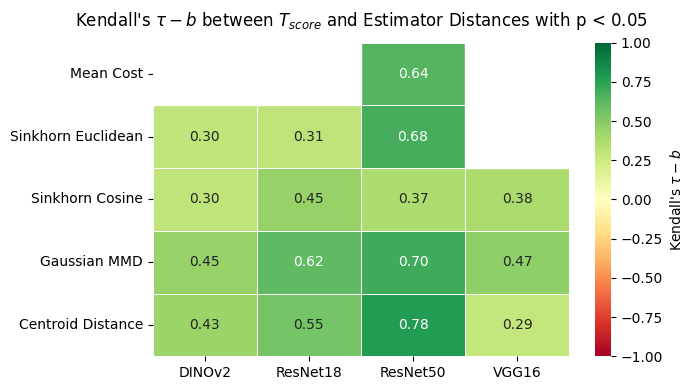

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

tau_matrix = results_df.pivot(index="metric", columns="backbone", values="tau")
sig_matrix = results_df.pivot(index="metric", columns="backbone", values="significant")

tau_matrix = tau_matrix.loc[list(METRIC_LABELS.keys()), list(BACKBONE_LABELS.keys())]
sig_matrix = sig_matrix.loc[list(METRIC_LABELS.keys()), list(BACKBONE_LABELS.keys())]

tau_matrix.index = [METRIC_LABELS[m] for m in tau_matrix.index]
tau_matrix.columns = [BACKBONE_LABELS[b] for b in tau_matrix.columns]
sig_matrix.index = tau_matrix.index
sig_matrix.columns = tau_matrix.columns

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(
    tau_matrix,
    ax=ax,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="RdYlGn",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": r"Kendall's $\tau-b$"},
)

for i, row in enumerate(tau_matrix.index):
    for j, col in enumerate(tau_matrix.columns):
        if not sig_matrix.loc[row, col]:
            ax.add_patch(
                mpatches.Rectangle(
                    (j, i),
                    1,
                    1,
                    fill=True,
                    color="white",
                    alpha=1,
                    zorder=3,
                    transform=ax.transData,
                )
            )

ax.set_title(
    r"Kendall's $\tau-b$ between $T_{score}$ and Estimator Distances with p < 0.05",
    pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()